## задание 4
Обучите модель из двух сверточных слоев на датасете CIFAR10, добейтесь значения метрики Accuracy в 70% на тестовой выборке. Ограничения касаются только количества сверточных слоев в архитектуре модели, можно использовать любые клевые штуки, что мы прошли на занятии. Вам нужно сдать код с функцией, которая возвращает модель, назовите эту функцию create_simple_conv_cifar. Она не принимает аргументов и возвращает модель. Также сдайте предсказание для тестовой выборки датасета CIFAR10, воспользуйтесь функцией predict из предыдущего задания. Воспользуйтесь torch.save для записи тензора с результатом предсказания на диск.

### 1. Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

### 2. Доступ к CUDA

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### 3. Загрузка датасета cifar 10 + функция для подсчета среднего и ст. отклонения

In [3]:
train_dataset = CIFAR10('../datasets/cifar10', train=True)
test_dataset  = CIFAR10('../datasets/cifar10', train=False)

def get_normalize(features):
    means = (features.data/255).mean(axis=(0, 1, 2))
    stds = (features.data/255).std(axis=(0, 1, 2))
    return means, stds

means, stds = get_normalize(train_dataset)
print(means, stds)

[0.49139968 0.48215841 0.44653091] [0.24703223 0.24348513 0.26158784]


### 4. Функция аугментации

In [4]:
def get_augmentations(train: bool=True, tta: bool=False) -> T.Compose:
    if train:
        train_transforms = T.Compose(
            [T.AutoAugment(T.AutoAugmentPolicy.CIFAR10),
             T.ToTensor(),
             T.Normalize(mean = means, std = stds)
            ]
        )
        return train_transforms
    else:
        test_transforms = T.Compose(
            [T.ToTensor(),
             T.Normalize(mean = means, std = stds)
            ]
        )
        return test_transforms

### 5. Создание датасетов

In [5]:
train_dataset = CIFAR10(
    '../datasets/cifar10',
    train=True,
    transform=get_augmentations(True),
    download=False
)

test_dataset = CIFAR10(
    '../datasets/cifar10',
    train=False,
    transform=get_augmentations(False),
    download=False
)

### 6. Создание даталоадеров

In [6]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
valid_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

### 7. Функция модели нейросети

In [7]:
def create_simple_conv_cifar() -> nn.Sequential:
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=256, kernel_size=3, padding=1),  # 32x32x256
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 16x16x256
        nn.Dropout2d(p=0.2),

        nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1),  # 16x16x128
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.MaxPool2d(2),  # 8x8x128
        nn.Dropout2d(p=0.2),

        nn.Flatten(),  # 8*8*128 = 8192
        nn.Linear(8*8*128, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )
    return model

### 16. ПОСЛЕДНЕЕ задание урока 4, функция ```create_advanced_conf_cifar```
Обучите любую модель на датасете CIFAR10, добейтесь значения метрики Accuracy в 88% на тестовой выборке. Вам нужно сдать код с функцией, которая возвращает модель, назовите эту функцию create_advanced_conv_cifar. Она не принимает аргументов и возвращает модель. Также сдайте предсказание для тестовой выборки датасета CIFAR10, воспользуйтесь функцией predict_tta из предыдущего задания (сравните результаты с помощью обычного predict и predict_tta, оцените какой прирост качества дает последняя), для того, чтобы использовать predict_tta нужно создать отдельно тестовый даталоадер с аугментациями. Воспользуйтесь torch.save для записи тензора с результатом предсказания на диск.

In [8]:
import math
Input_size= 8
Padding = 1
Dilation = 1
Kernel_size = 3
Stride =1
output_size = math.floor( (Input_size + 2 * Padding - Dilation * (Kernel_size - 1) - 1) / Stride + 1 )
output_size

8

In [9]:
def create_advanced_conf_cifar():
    model_final = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1), ### пишу размер, который стал: 32x32x64
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),

        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1), ### пишу размер, который стал: 32x32x64
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, dilation=2), ### 30x30x128
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),

        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, dilation=2), ### 28x28x128
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2), ### 14x14x128
        nn.Dropout2d(p=0.2),


        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=3, dilation=2), ### 16x16x256
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2), ### 8x8x256
        nn.Dropout2d(p=0.2),
        

        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1), ### 8x8x256
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),
        


        nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=2, dilation=2), ### 8x8x512
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.MaxPool2d(2), ### 4x4x512
        nn.Dropout2d(p=0.2),


        nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1), ### 4x4x256
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),

        nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1), ### 4x4x128
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),

        nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1), ### 4x4x64
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Dropout2d(p=0.2),
        

        nn.Flatten(),

        nn.Linear(4*4*64, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, 10),
    )
    return model_final

### ЗАДАНИЕ ИЗ 5 УРОКА
Модифицируйте свою лучшую модель из 4-го занятия 10-го задания, добавьте в нее skip-connection. Обучите ее на CIFAR10. Сравните качество со skip-connection и без skip-connection. Добейтесь Accuracy в 88.5% на тестовой выборке.
Вам нужно сдать код с функцией, которая возвращает модель, назовите эту функцию create_advanced_skip_connection_conv_cifar

In [10]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        # блоки архитектуры
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1), ### пишу размер, который стал: 32x32x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p=0.2)
        )
        
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1), ### пишу размер, который стал: 32x32x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p=0.2)
        )

        self.block_3 = nn.Sequential(
             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, dilation=2), ### 30x30x128
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p=0.2)
        )

        self.block_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, dilation=2), ### 28x28x128
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), ### 14x14x128
            nn.Dropout2d(p=0.2),
        )

        self.block_5 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=3, dilation=2), ### 16x16x256
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2), ### 8x8x256
            nn.Dropout2d(p=0.2),
        )

        self.block_6 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1), ### 8x8x256
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(p=0.2),
        )

        self.block_7 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=2, dilation=2), ### 8x8x512
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2), ### 4x4x512
            nn.Dropout2d(p=0.2),
        )

        self.block_8 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=128, kernel_size=3, padding=1), ### 4x4x128
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p=0.2),
        )

        self.block_9 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), ### 4x4x128
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p=0.2),
        )

        self.block_10 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1), ### 4x4x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p=0.2),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(4*4*64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.fc3 = nn.Linear(128, 10)

    def forward(self,x):
        x = self.block_1(x)
        skip = x
        x = self.block_2(x)
        x = x + skip
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.block_5(x)
        skip = x
        x = self.block_6(x)
        x = x + skip
        x = self.block_7(x)
        x = self.block_8(x)
        skip = x
        x = self.block_9(x)
        x = x + skip
        x = self.block_10(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)

        return x
        

def create_advanced_skip_connection_conf_cifar():
    return Model()  

In [11]:
print(create_advanced_skip_connection_conf_cifar())

Model(
  (block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
  )
  (block_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
  )
  (block_3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=(2, 2))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
  )
  (block_4): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), dilation=(2, 2))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()


### 9. Функция обучения в режиме трейн

In [12]:
#!g1.1
def train(model) -> float:
    model.train()

    train_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(train_loader, desc='Train'):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()
        
        _, y_pred = torch.max(output, 1)
        total += y.size(0)
        correct += (y_pred == y).sum().item()

    train_loss /= len(train_loader)
    accuracy = correct / total

    return train_loss, accuracy

### 10. Функция evaluate

In [13]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    valid_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(loader, desc='Valid'):
        x, y = x.to(device), y.to(device)

        output = model(x)
        loss = loss_fn(output, y)

        valid_loss += loss.item()

        _, y_pred = torch.max(output, 1)
        total += y.size(0)
        correct += (y_pred == y).sum().item()

    valid_loss /= len(loader)
    accuracy = correct / total

    return valid_loss, accuracy

### 11. Функция для предсказания классов по батчам даталоадера

In [14]:
@torch.inference_mode()  
def predict(model: nn.Module, loader: DataLoader, device: torch.device):
    
    model.eval()
    
    preds = []

    for x, y in tqdm(loader):

        x, y = x.to(device), y.to(device)

        logits = model(x)

        pred = torch.argmax(logits, dim=1)

        preds.append(pred.cpu())

    preds_tensor = torch.cat(preds)
    return preds_tensor


### 12. Функция для рисовки графиков

In [15]:
from IPython.display import clear_output

def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))
    plt.title(title + ' loss')
    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(16, 8))
    plt.title(title + ' accuracy')
    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()
    plt.grid()
    plt.show()

### 13. Функция обучение по эпохам в цикле

In [17]:
def whole_train_valid_cycle(model, num_epochs, title):
    # Создаем атрибуты в модели для хранения истории
    model.train_loss_history = []
    model.valid_loss_history = []
    model.train_accuracy_history = []
    model.valid_accuracy_history = []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model)
        valid_loss, valid_accuracy = evaluate(model, valid_loader)

        model.train_loss_history.append(train_loss)
        model.valid_loss_history.append(valid_loss)
        model.train_accuracy_history.append(train_accuracy)
        model.valid_accuracy_history.append(valid_accuracy)

        clear_output()
        plot_stats(
            model.train_loss_history, model.valid_loss_history,
            model.train_accuracy_history, model.valid_accuracy_history,
            title
        )

        scheduler.step()

        if model.valid_accuracy_history[-1] >= 0.885:
            print(f"✅ Достигнута точность {model.valid_accuracy_history[-1]:.2%}")
            break

### 8. Грузим модель на видюху + функция потерь + оптимизатор

In [18]:
#model = create_simple_conv_cifar().to(device)
#model = create_advanced_conf_cifar().to(device)
model = create_advanced_skip_connection_conf_cifar().to(device)

from torch.optim.lr_scheduler import StepLR

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = StepLR(optimizer, step_size=25)

### 14. Запуск обучения

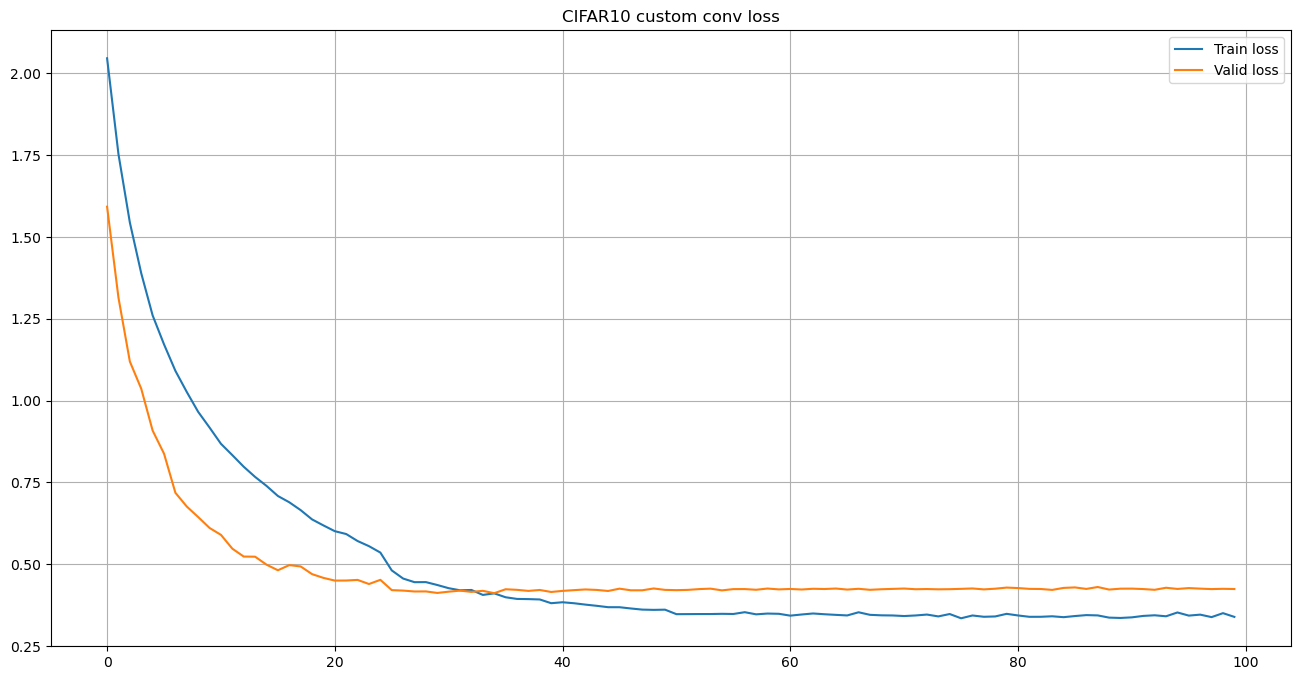

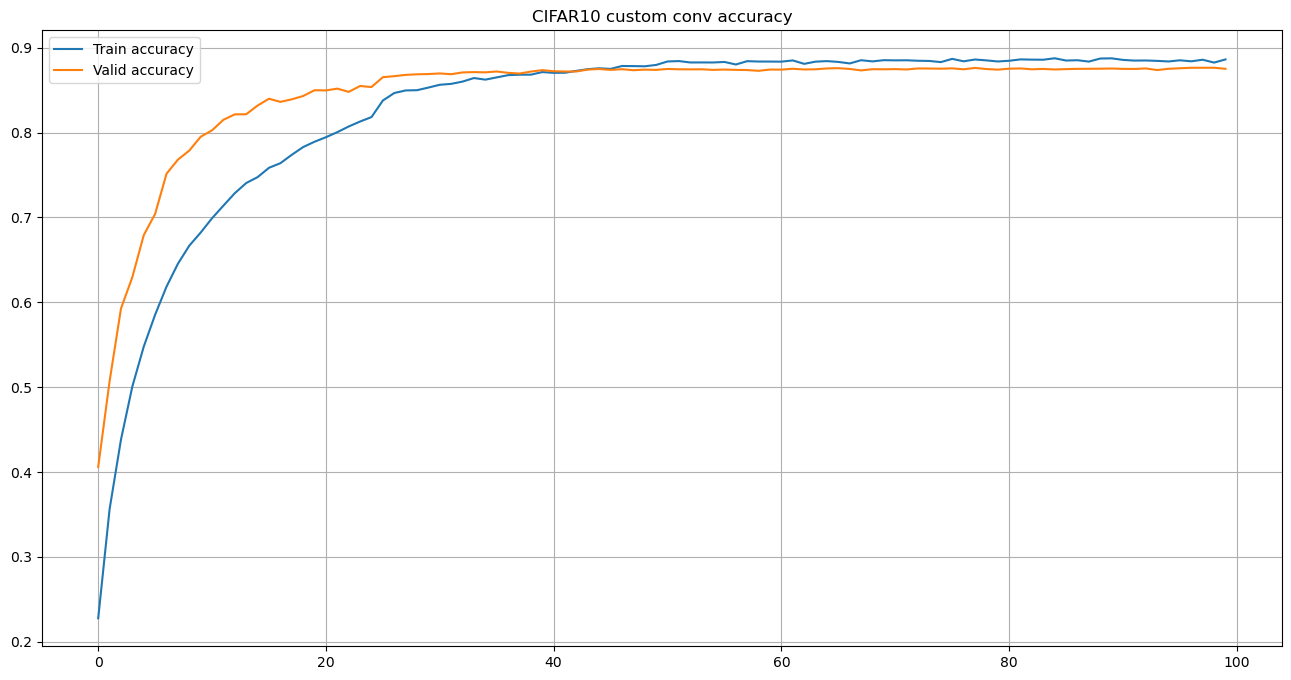

In [19]:
whole_train_valid_cycle(model, num_epochs=100, title='CIFAR10 custom conv')

In [25]:
max(model.valid_accuracy_history)

0.8765

### 15. Запись тензора предсказаний

In [33]:
@torch.inference_mode()
def predict_tta(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    iterations: int = 2
):
    model.eval()

    tta_logits = []  # сюда будем складывать [N, C], где N — количество объектов, C — количество классов для каждой итерации, два таких тензора соответсвенно по количеству операций

    for _ in range(iterations):

        all_logits = []  # логиты за проход по датасету, будет столько тензорв размерности [B, C] в списке all_logits, сколько всего батчей

        for x, y in tqdm(loader):
            x = x.to(device)

            logits = model(x)  # [B, C]
            all_logits.append(logits.cpu())  # переносим на CPU, чтобы не переполнить GPU

        all_logits = torch.cat(all_logits, dim=0)  # объединяем тензоры по строкам так, что B+B+B+.. = N --> [N, C] итоговая размерность
        tta_logits.append(all_logits) # аналогично складываем в нашем случае два тензора размером [N, C]

    # делаем [N, C, iterations]
    tta_logits = torch.stack(tta_logits, dim=2) # создаем третью ось, как будто в 3 д, у нас будет по оси икс количество объектов (N штук), 
    # по y классы (10 штук) , а по z теперь еще добавится один слой
    # грубо говоря для понимания было два 2D слоя (тензора) друг под другом (сверху и снизку),
    # а стало два 2D слоя друг за другом (спереди и сзазди), как в 3 д матрице

    # усредняем по итерациям
    mean_logits = tta_logits.mean(dim=2)  # [N, C] # усредняем по этим двум слоям( dim это не слой), для соответсвующих элементов

    # предсказываем классы
    preds = mean_logits.argmax(dim=1)  # [N], для каждого объекта оставили только самый вероятнейший класс, поэтому стал размер N по количеству объектов, вектор столбец


    return preds

In [34]:
# Создаем TTA даталоадер (с аугментациями)
test_tta_dataset = CIFAR10(
    '../datasets/cifar10',
    train=False,
    transform=get_augmentations(train=False, tta=True),  # используем tta=True
    download=False
)

test_tta_loader = DataLoader(test_tta_dataset, batch_size=128, shuffle=False, num_workers=2)

# Получаем предсказания
print("Обычный predict...")
preds_normal = predict(model, valid_loader, device)

print("TTA predict...")
preds_tta = predict_tta(model, test_tta_loader, device, iterations=4)

# Сравниваем с реальными метками
true_labels = torch.cat([y for _, y in valid_loader])

acc_normal = (preds_normal == true_labels).float().mean() * 100
acc_tta = (preds_tta == true_labels).float().mean() * 100

print(f"\nОбычный predict accuracy: {acc_normal:.2f}%")
print(f"TTA predict accuracy: {acc_tta:.2f}%")
print(f"Прирост: +{acc_tta - acc_normal:.2f}%")

# Сохраняем предсказания
torch.save(preds_tta, 'cifar10_predictions.pt')
print("\nПредсказания сохранены в 'cifar10_predictions.pt'")

Обычный predict...


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:07<00:00, 10.54it/s]


TTA predict...


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:07<00:00, 10.48it/s]



Обычный predict accuracy: 88.19%
TTA predict accuracy: 88.19%
Прирост: +0.00%

Предсказания сохранены в 'cifar10_predictions.pt'
